# Tennis Match Analysis
## Match Intensity and Duration: Predicting Time from Points Played

This notebook analyzes the relationship between match intensity (total points played) and match duration in ATP tennis. We investigate whether the number of points played is a reliable predictor of match length.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast  

# Load data
df = pd.read_csv('Cleaned_dataset.csv')


print(df.info()) 
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9871 entries, 0 to 9870
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   pbp_id              9871 non-null   int64 
 1   date                9871 non-null   object
 2   tny_name            9871 non-null   object
 3   tour                9871 non-null   object
 4   draw                9871 non-null   object
 5   server1             9871 non-null   object
 6   server2             9871 non-null   object
 7   winner              9871 non-null   int64 
 8   pbp                 9871 non-null   object
 9   score               9871 non-null   object
 10  adf_flag            9871 non-null   int64 
 11  wh_minutes          9871 non-null   int64 
 12  score_winner_valid  9871 non-null   bool  
 13  pbp_fixed           9871 non-null   object
 14  pbp_set_count       9871 non-null   int64 
 15  score_set_count     9871 non-null   int64 
 16  set_count_match     9871

## 1. Data Validation and Cleaning
Ensure data quality by filtering for reasonable match durations and valid dates.

### Filters Applied:
- **Duration**: 30–500 minutes (removes outliers)
- **Date Format**: Coerce invalid dates to NaT
- **Missing Values**: Drop rows with missing critical fields

In [ ]:

df = df[(df['wh_minutes'] > 30) & (df['wh_minutes'] < 500)].copy()


df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 3. Drop rows with missing critical info
df = df.dropna(subset=['date', 'pbp_set_winners'])

/var/folders/rz/3q9t0_5s4tjdszvw2wf1swvh0000gn/T/ipykernel_30980/3277969807.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['date'] = pd.to_datetime(df['date'], errors='coerce')


## 3. Calculate Match Intensity (Total Points Played)
### 

**Methodology:**
Parse the point-by-point (pbp) data to count total points played in each match.

**Point Notation:**
- `S` = Server wins point
- `R` = Receiver wins point
- `A` = Ace (converted to S)
- `D` = Double fault (converted to R)
- `;` = Game separator (removed)
- `.` = Set separator (removed)
- `/` = Serve switch in tiebreak (removed)

**Process:**
1. Normalize special characters (A → S, D → R)
2. Remove delimiters (;, ., /)
3. Count remaining characters = total points

In [12]:
# 4. Calculate Intensity (Total points played)
df['total_points'] = (
    df['pbp']
    .str.replace('A', 'S', regex=False)
    .str.replace('D', 'R', regex=False)
    .str.replace(';', '', regex=False)
    .str.replace('.', '', regex=False)
    .str.replace('/', '', regex=False)
    .str.len()
)

### Data Quality Check
Verify all features are properly engineered.

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8980 entries, 0 to 9870
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   pbp_id              8980 non-null   int64         
 1   date                8980 non-null   datetime64[ns]
 2   tny_name            8980 non-null   object        
 3   tour                8980 non-null   object        
 4   draw                8980 non-null   object        
 5   server1             8980 non-null   object        
 6   server2             8980 non-null   object        
 7   winner              8980 non-null   int64         
 8   pbp                 8980 non-null   object        
 9   score               8980 non-null   object        
 10  adf_flag            8980 non-null   int64         
 11  wh_minutes          8980 non-null   int64         
 12  score_winner_valid  8980 non-null   bool          
 13  pbp_fixed           8980 non-null   object        
 1

## 4. Analysis: Points vs. Duration Correlation

### Hypothesis
The number of points played in a match should be strongly correlated with match duration. More points = longer matches.

### Expected Outcome
High positive correlation (>0.7) indicates that point count is a reliable predictor of match length.

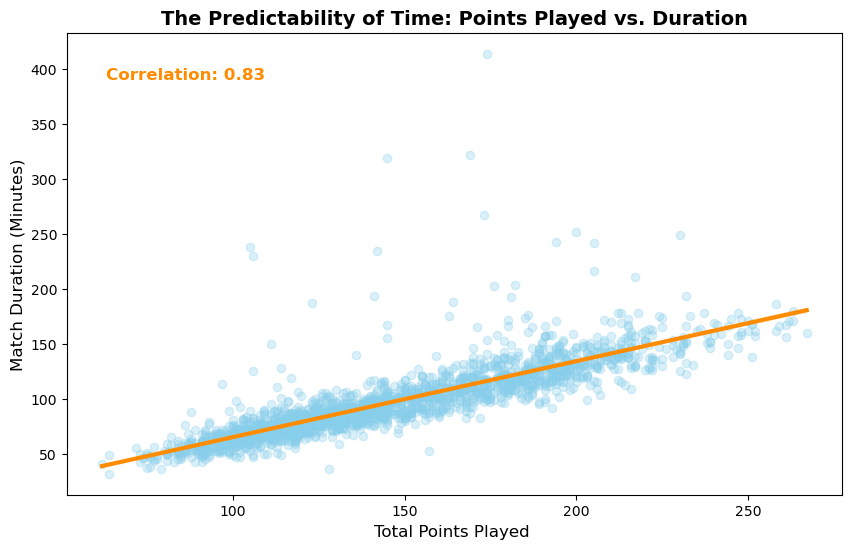

In [ ]:

plt.figure(figsize=(10, 6))
# We use a sample of 2000 for a cleaner plot if the data is dense
sns.regplot(data=df.sample(2000), x='total_points', y='wh_minutes', 
            scatter_kws={'alpha': 0.3, 'color': 'skyblue'}, 
            line_kws={'color': 'darkorange', 'lw': 3})

plt.title('The Predictability of Time: Points Played vs. Duration', fontsize=14, fontweight='bold')
plt.xlabel('Total Points Played ', fontsize=12)
plt.ylabel('Match Duration (Minutes)', fontsize=12)

# Calculate correlation to add to your narrative
corr = df['total_points'].corr(df['wh_minutes'])
plt.annotate(f'Correlation: {corr:.2f}', xy=(0.05, 0.9), xycoords='axes fraction', 
             fontsize=12, fontweight='bold', color='darkorange')

plt.savefig('visual5_points_vs_duration.png')

